# Fase 2 — Limpieza de datos y Análisis Exploratorio (EDA)

**TP1 — Regresión e Introducción a la Evaluación de Modelos**
Materia 72.75 — Aprendizaje Automático — ITBA

Cubre las consignas **1.2 (valores faltantes)** y **1.3 (outliers)** del enunciado.

---

## Ubicación en el pipeline

| Paso | Etapa | Estado |
|---|---|---|
| 1–3 | Definición, recolección y **Data Splitting** | ✅ Fase 1 |
| 4 | **Limpieza de datos** — missing values, outliers, inconsistencias | ✅ **este notebook** |
| 5 | **EDA** — distribuciones, correlaciones, insights iniciales | ✅ **este notebook** |
| 6 | Feature engineering / selection | Fases 3 y 5 |
| 7–9 | Modelado, regularización, evaluación en Dev | Fases 4 y 5 |
| 11 | Selección del modelo y evaluación final en Test | Fase 6 |

## Regla que gobierna todo este notebook

> **Sólo se mira el train.** El test se separó en la Fase 1 y no se vuelve a abrir hasta
> la Fase 6.

Todo lo que se calcula acá —medias, medianas, cuartiles, IQR, desvíos, correlaciones— son
**estadísticos**. Calcularlos sobre el dataset completo sería exactamente el data leakage
que la Clase 2 advierte en las slides 93–96. Por eso este notebook entra por
`cargar_splits()` y nunca por `cargar_datos_crudos()`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import TARGET, FIGURES_DIR
from src.data import cargar_splits
from src.exploracion import (
    resumen_faltantes,
    limites_iqr,
    outliers_iqr,
    outliers_zscore,
    resumen_outliers,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 110)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train, _test_no_tocar = cargar_splits()

NUMERICAS = ["age", "bmi", "children"]
CATEGORICAS = ["sex", "smoker", "region"]

print(f"Train: {train.shape[0]} filas x {train.shape[1]} columnas")
print(f"Target: {TARGET}")
print("\nEl test esta cargado pero NO se usa en este notebook.")

Train: 1070 filas x 7 columnas
Target: charges

El test esta cargado pero NO se usa en este notebook.


---

# Parte 1 — Limpieza de datos *(paso 4 del pipeline)*

La Clase 2 (slide 26) enumera los problemas a revisar antes de entrenar:

- Valores faltantes / erróneos
- Outliers
- Datos duplicados

Los recorremos en ese orden.

## 1.1 Valores faltantes *(consigna 1.2)*

Estrategias vistas en clase (Clase 2, slide 31):

| Estrategia | Cuándo aplicarla |
|---|---|
| Quitar todo el dato (la fila) | Datasets grandes; con datasets chicos conviene evitarlo |
| Quitar la variable | Si el % de faltantes de esa columna es alto (**~20%**) |
| Imputar un valor | Estadísticos globales (media, mediana, moda), estadísticos por grupo, o valor constante |

In [2]:
faltantes = resumen_faltantes(train)
faltantes

,n_faltantes,pct_faltantes
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


In [3]:
total_na = int(train.isna().sum().sum())
print(f"Total de valores faltantes en el train: {total_na}")
print(f"Filas completas: {train.notna().all(axis=1).sum()} de {len(train)} "
      f"({train.notna().all(axis=1).mean():.1%})")

Total de valores faltantes en el train: 0
Filas completas: 1070 de 1070 (100.0%)


**Resultado: el dataset no tiene valores faltantes.** Ninguna de las 7 columnas presenta
un solo `NaN` en las 1070 filas del train.

**Decisión: no se aplica ninguna estrategia de tratamiento de faltantes**, porque no hay nada
que tratar. No se elimina ninguna fila, no se descarta ninguna variable y no se imputa
ningún valor.

> **Por qué se documenta igual.** El análisis es parte de la consigna 1.2 aunque el
> resultado sea negativo: hay que mostrar que se verificó, no asumirlo. Además, el
> `Pipeline` de la Fase 3 podría incluir igualmente un `SimpleImputer` como red de
> seguridad, para que el modelo no falle si en producción llegara un registro con un
> campo vacío. Esa decisión se toma en la Fase 3.

## 1.2 Datos duplicados

En la Fase 1 se detectó que el dataset crudo contenía **un par de filas exactamente
idénticas** (índices 195 y 581), y que el split las repartió: la 195 quedó en train y la
581 en test.

Corresponde ahora verificar cuántos duplicados quedan **dentro del train**, que es el
conjunto sobre el que podemos actuar.

In [4]:
n_dup = train.duplicated().sum()
print(f"Filas exactamente duplicadas dentro del train: {n_dup}")

if n_dup:
    display(train[train.duplicated(keep=False)].sort_values(list(train.columns)))
else:
    print("\nNo hay ninguna fila repetida dentro del train.")
    print("La unica copia del par duplicado que quedo de este lado es el indice 195.")
    print("Su gemela (581) esta en el test, que no se toca.")

Filas exactamente duplicadas dentro del train: 0

No hay ninguna fila repetida dentro del train.
La unica copia del par duplicado que quedo de este lado es el indice 195.
Su gemela (581) esta en el test, que no se toca.


**Resultado: 0 duplicados dentro del train.** No hay nada que eliminar.

La fila 195 aparece una sola vez de este lado; su copia idéntica está en el test. Esa
situación quedó documentada y cuantificada en la Fase 1 (1 fila = 0.37% del test) y se
sostiene la decisión de no intervenir el test.

## 1.3 Inconsistencias y rangos válidos

La Clase 2 (slide 26) menciona los "valores erróneos" junto a los faltantes. A diferencia
de un outlier —que es un valor extremo pero posible— una inconsistencia es un valor
**imposible**: una edad negativa, un BMI de cero, un costo menor que cero.

In [5]:
print("--- Rango observado de cada variable numerica ---")
display(train[NUMERICAS + [TARGET]].describe().T.round(2))

controles = {
    "age fuera de [18, 64]": int(((train["age"] < 18) | (train["age"] > 64)).sum()),
    "bmi fuera de [10, 60]": int(((train["bmi"] < 10) | (train["bmi"] > 60)).sum()),
    "children negativo": int((train["children"] < 0).sum()),
    f"{TARGET} <= 0": int((train[TARGET] <= 0).sum()),
    "categorias inesperadas en sex": int((~train["sex"].isin(["male", "female"])).sum()),
    "categorias inesperadas en smoker": int((~train["smoker"].isin(["yes", "no"])).sum()),
}

print("\n--- Controles de consistencia ---")
for nombre, n in controles.items():
    estado = "OK" if n == 0 else f"REVISAR ({n})"
    print(f"  {nombre:<35}: {estado}")

--- Rango observado de cada variable numerica ---


,count,mean,std,min,25%,50%,75%,max
age,1070.0,39.36,14.07,18.00,27.00,39.50,51.00,64.00
bmi,1070.0,30.56,6.04,15.96,26.20,30.21,34.50,53.13
children,1070.0,1.11,1.22,0.00,0.00,1.00,2.00,5.00
charges,1070.0,13346.09,12019.51,1121.87,4897.67,9575.44,16746.66,62592.87



--- Controles de consistencia ---
  age fuera de [18, 64]              : OK
  bmi fuera de [10, 60]              : OK
  children negativo                  : OK
  charges <= 0                       : OK
  categorias inesperadas en sex      : OK
  categorias inesperadas en smoker   : OK


**Resultado: no se detectaron inconsistencias.**

- `age` va de 18 a 64: coherente con una población de adultos asegurados.
- `bmi` va de 15.96 a 53.13: valores fisiológicamente posibles (desde bajo peso hasta
  obesidad severa).
- `children` va de 0 a 5, sin negativos. Los 456 registros con `children = 0` no son un
  error: son personas sin hijos a cargo.
- `charges` es siempre positivo, con mínimo de \$1121.87.
- Las categóricas sólo contienen los niveles esperados.

**Decisión: no se corrige ni se elimina ningún registro por inconsistencia.**

## 1.4 Outliers *(consigna 1.3)*

La consigna pide analizar la presencia de valores atípicos en las variables numéricas,
indicar **qué criterio** se usa para detectarlos y **justificar si se eliminan o se
mantienen**.

Se aplican los dos enfoques de la Clase 2:

- **Métodos visuales (slide 40):** histogramas, boxplots y scatter plots.
- **Métodos estadísticos (slide 41):** criterio IQR y criterio z-score (`|z| > 3`).

La propia slide 40 aclara por qué hacen falta los dos: los métodos visuales
*"generalmente necesitan de un estadístico para justificar la eliminación del outlier"*.

### 1.4.1 Detección visual: histogramas

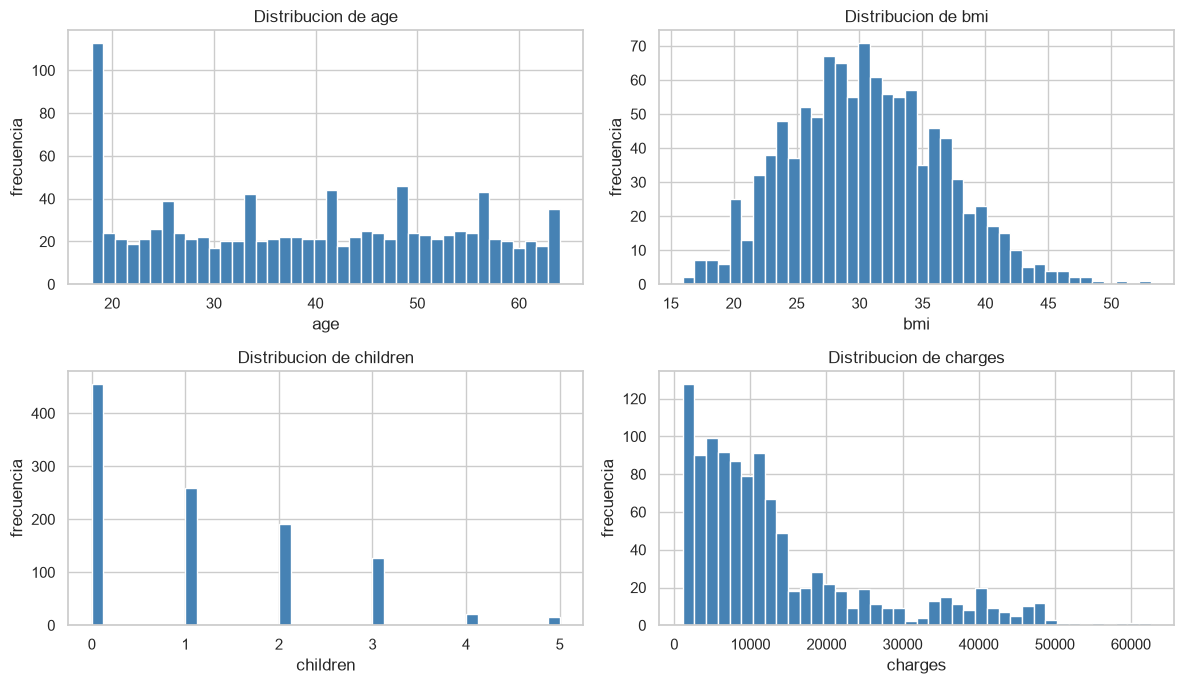

In [6]:
cols_plot = NUMERICAS + [TARGET]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for ax, col in zip(axes.ravel(), cols_plot):
    ax.hist(train[col], bins=40, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribucion de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("frecuencia")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_histogramas.png", dpi=150, bbox_inches="tight")
plt.show()

Primera lectura:

- `age` es casi uniforme, con un pico en los más jóvenes. Sin cola extrema.
- `bmi` es aproximadamente simétrica, con forma de campana. Es la única candidata razonable
  a un tratamiento gaussiano.
- `children` es discreta y muy concentrada en 0, 1 y 2.
- **`charges` está fuertemente sesgada a la derecha y muestra dos "montañas"**: una masa
  grande de costos bajos y un grupo separado de costos altos. Eso no es una cola: es la
  firma de **dos poblaciones distintas** conviviendo en la misma variable (Clase 3,
  slides 37–38).

### 1.4.2 Detección visual: boxplots

El boxplot es el método visual que la Clase 2 (slide 40) señala explícitamente porque
*"hace estadística basada en IQR para marcar outlier"*: los puntos que dibuja fuera de los
bigotes son exactamente los que detecta el criterio IQR con k = 1.5.

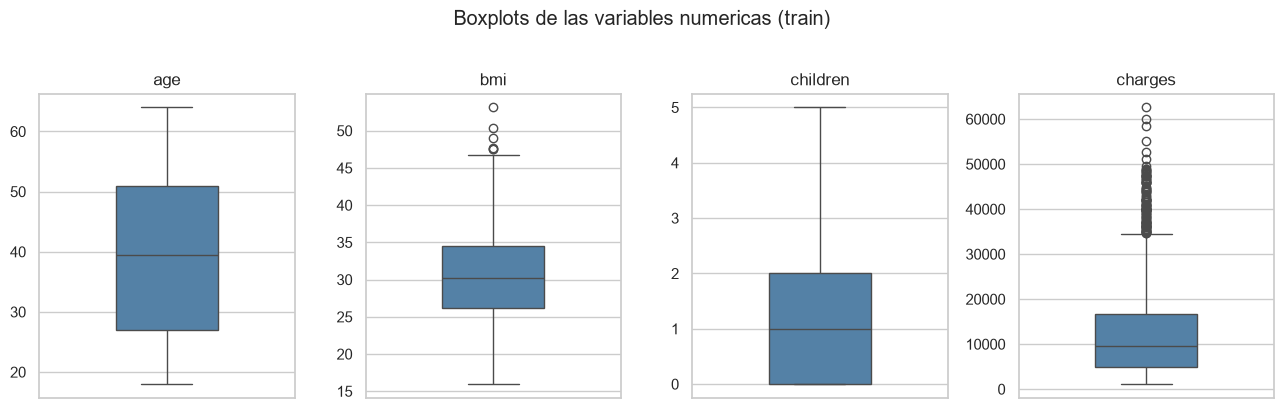

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4))

for ax, col in zip(axes, cols_plot):
    sns.boxplot(y=train[col], ax=ax, color="steelblue", width=0.4)
    ax.set_title(col)
    ax.set_ylabel("")

plt.suptitle("Boxplots de las variables numericas (train)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.4.3 Detección estadística: IQR vs z-score

- **Criterio IQR** (Clase 2, slide 41): es outlier si el valor cae fuera de
  $[Q_1 - 1.5\,\text{IQR},\; Q_3 + 1.5\,\text{IQR}]$.
- **Criterio z-score** (Clase 2, slide 41): es outlier si $|z| > 3$, con
  $z = (x - \mu)/\sigma$.

Ambos se calculan **sólo con el train**.

In [8]:
tabla_outliers = resumen_outliers(train, cols_plot)
tabla_outliers

,lim_inf_IQR,lim_sup_IQR,n_IQR,pct_IQR,n_zscore,pct_zscore
variable,,,,,,
age,-9.00,87.00,0,0.00,0,0.00
bmi,13.77,46.93,6,0.56,3,0.28
children,-3.00,5.00,0,0.00,15,1.40
charges,-12875.82,34520.14,111,10.37,7,0.65


**Los dos criterios no coinciden, y la diferencia es informativa:**

| Variable | IQR | z-score | Lectura |
|---|---|---|---|
| `age` | 0 | 0 | Sin atípicos por ningún criterio |
| `bmi` | 6 (0.6%) | 3 (0.3%) | Unos pocos casos de obesidad severa |
| `children` | 0 | 15 (1.4%) | Los 15 son personas con 5 hijos: valor legítimo |
| **`charges`** | **111 (10.4%)** | **7 (0.7%)** | **Discrepancia enorme** |

La discrepancia en `charges` tiene una explicación estadística: el criterio z-score usa la
**media y el desvío**, que son estadísticos **no robustos** — los propios valores extremos
los inflan, y el umbral $|z|>3$ se corre hacia afuera. El IQR usa cuartiles, que son
robustos, y por eso marca mucho más.

Que un criterio señale el **10.4% de los datos** como atípicos es en sí mismo una señal de
alarma: si una de cada diez observaciones es "rara", probablemente el problema no sean los
datos sino el supuesto de que hay una sola población.

### 1.4.4 ¿Quiénes son los outliers de `charges`?

Antes de decidir si se eliminan, hay que mirar **qué son**. La Clase 2 (slide 44) lo pide
explícitamente: *"antes de imputar o eliminar aquí, mirar si..."*.

In [9]:
mask_out = outliers_iqr(train[TARGET])
outliers = train[mask_out]

print(f"Outliers de charges por IQR: {len(outliers)} filas ({mask_out.mean():.1%} del train)\n")

print("Composicion por condicion de fumador:")
comp = pd.DataFrame({
    "n_outliers": outliers["smoker"].value_counts(),
    "n_train": train["smoker"].value_counts(),
})
comp["% del grupo que es outlier"] = (100 * comp["n_outliers"] / comp["n_train"]).round(1)
display(comp)

print(f"% de fumadores DENTRO de los outliers : {(outliers['smoker'] == 'yes').mean():.1%}")
print(f"% de fumadores en el train completo   : {(train['smoker'] == 'yes').mean():.1%}")

Outliers de charges por IQR: 111 filas (10.4% del train)

Composicion por condicion de fumador:


,n_outliers,n_train,% del grupo que es outlier
smoker,,,
no,3,850,0.4
yes,108,220,49.1


% de fumadores DENTRO de los outliers : 97.3%
% de fumadores en el train completo   : 20.6%


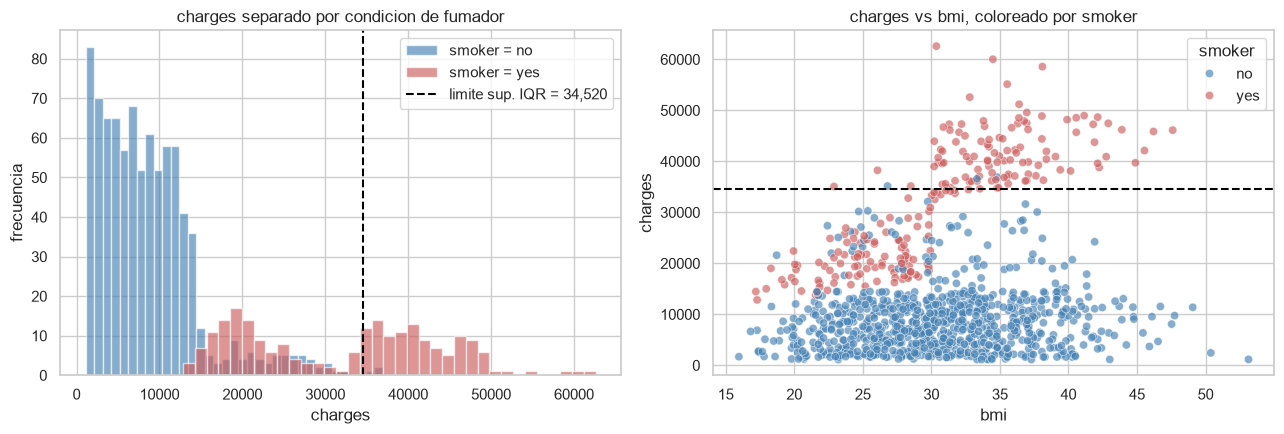

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for fuma, color in [("no", "steelblue"), ("yes", "indianred")]:
    axes[0].hist(train.loc[train["smoker"] == fuma, TARGET], bins=35, alpha=0.65,
                 label=f"smoker = {fuma}", color=color)
li, ls = limites_iqr(train[TARGET])
axes[0].axvline(ls, color="black", linestyle="--", linewidth=1.5,
                label=f"limite sup. IQR = {ls:,.0f}")
axes[0].set_title("charges separado por condicion de fumador")
axes[0].set_xlabel("charges")
axes[0].set_ylabel("frecuencia")
axes[0].legend()

sns.scatterplot(data=train, x="bmi", y=TARGET, hue="smoker", alpha=0.65,
                palette={"no": "steelblue", "yes": "indianred"}, ax=axes[1])
axes[1].axhline(ls, color="black", linestyle="--", linewidth=1.5)
axes[1].set_title("charges vs bmi, coloreado por smoker")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_charges_por_smoker.png", dpi=150, bbox_inches="tight")
plt.show()

**Acá está la respuesta.** Los 111 "outliers" de `charges` son, en un **97.3%**,
fumadores. Y visto al revés: **el 49% de todos los fumadores del train** cae fuera del
límite IQR.

El panel izquierdo muestra que la bimodalidad del histograma de `charges` **es exactamente
la separación entre fumadores y no fumadores**: dos distribuciones distintas superpuestas.
El panel derecho muestra que los puntos por encima de la línea no son ruido disperso, sino
una estructura ordenada — la nube roja crece con el `bmi` de forma clara.

Es el caso descrito en la Clase 3 (slides 37–38): un histograma con dos picos que revela
**dos poblaciones**, no valores erróneos.

In [11]:
fum = train["smoker"] == "yes"
n_perdidos = int((mask_out & fum).sum())

print("SI SE ELIMINARAN LOS OUTLIERS DE charges POR IQR:")
print(f"  se irian {mask_out.sum()} filas de {len(train)} ({mask_out.mean():.1%} del train)")
print(f"  de ellas {n_perdidos} son fumadores")
print(f"  se perderia el {n_perdidos / fum.sum():.1%} de TODOS los fumadores del train")
print(f"  la proporcion de fumadores caeria de {fum.mean():.1%} a "
      f"{(fum & ~mask_out).sum() / (~mask_out).sum():.1%}")
print()
print("  Es decir: se estaria borrando la mitad de la evidencia sobre la variable")
print("  que mas explica el target.")

SI SE ELIMINARAN LOS OUTLIERS DE charges POR IQR:
  se irian 111 filas de 1070 (10.4% del train)
  de ellas 108 son fumadores
  se perderia el 49.1% de TODOS los fumadores del train
  la proporcion de fumadores caeria de 20.6% a 11.7%

  Es decir: se estaria borrando la mitad de la evidencia sobre la variable
  que mas explica el target.


### 1.4.5 Decisión sobre los outliers

Estrategias vistas en clase (Clase 2, slide 42):

1. **Eliminar el dato** — *"si no son errores sino que representan un dato raro"*.
2. **Transformaciones estadísticas** que reduzcan su efecto.
3. **Usar modelos más robustos** a outliers.

---

**Decisión: se mantienen todos los registros. No se elimina ninguna fila por outlier.**

**Justificación:**

1. **No son errores de medición ni valores imposibles.** El control de consistencia
   (sección 1.3) no encontró ningún valor fuera de rango. Un costo médico de \$50.000 para
   un fumador con obesidad es perfectamente plausible.

2. **No son "datos raros": son la señal principal del problema.** El 97.3% de ellos son
   fumadores, y el efecto del tabaquismo sobre el costo médico es justamente lo que el
   modelo tiene que aprender. Eliminarlos sería quitar del entrenamiento la mitad de los
   fumadores y dejar un modelo incapaz de predecir el segmento más caro — que es
   precisamente el que más le importa a una aseguradora.

3. **El criterio IQR no es aplicable acá tal como está.** Marca el 10.4% de los datos
   porque asume una distribución unimodal, y `charges` es bimodal por construcción. El IQR
   está midiendo la distancia entre dos poblaciones, no la rareza dentro de una.

4. **`charges` es el target, no una feature.** El criterio de la Clase 2 apunta a valores
   atípicos en las variables de entrada. Recortar el target equivaldría a redefinir el
   problema: el modelo dejaría de predecir "el costo médico" para predecir "el costo médico
   de los casos baratos".

**Sobre `bmi`:** los 6 casos que marca el IQR (entre 47.5 y 53.1) son de obesidad severa,
fisiológicamente posibles, y su costo medio (\$13.155) es prácticamente igual al del resto
del train (\$13.347). No aportan distorsión. **Se mantienen.**

**Sobre `children`:** los 15 casos que marca el z-score son personas con 5 hijos. Es un
valor legítimo de una variable discreta con rango 0–5. **Se mantienen.**

---

**Estrategias 2 y 3 de la slide 42, que sí se aplican en las fases siguientes:**

- La **estrategia 3 (modelos robustos)** se materializa en la **regularización L1** de la
  Fase 5: penalizar coeficientes grandes limita cuánto puede el modelo dejarse arrastrar
  por observaciones extremas.
- La **estrategia 2 (transformaciones)** se evalúa en la Fase 3: la asimetría de `charges`
  admite una transformación logarítmica. Se documenta allí la decisión.

En lugar de eliminar los valores extremos, se le da al modelo la variable que los explica:
`smoker` entra como feature, tal como sugiere la Clase 3 (slide 38) al recomendar crear una
variable que identifique la población. Acá esa variable **ya existe en el dataset**.

---

# Parte 2 — Análisis Exploratorio de Datos *(paso 5 del pipeline)*

La Clase 3 (slide 33) define los objetivos del EDA:

- detectar problemas en los datos *(hecho en la Parte 1)*
- entender las variables del dataset
- descubrir relaciones entre variables

## 2.1 Estadísticas descriptivas

*"Media, mediana, desviación estándar, mínimos y máximos permiten obtener una primera
comprensión de los datos"* (Clase 3, slide 34).

In [12]:
display(train[NUMERICAS + [TARGET]].describe().T.round(2))

print("Distribucion de las variables categoricas (%):")
for col in CATEGORICAS:
    print(f"\n-- {col} --")
    print((100 * train[col].value_counts(normalize=True)).round(1).to_string())

,count,mean,std,min,25%,50%,75%,max
age,1070.0,39.36,14.07,18.00,27.00,39.50,51.00,64.00
bmi,1070.0,30.56,6.04,15.96,26.20,30.21,34.50,53.13
children,1070.0,1.11,1.22,0.00,0.00,1.00,2.00,5.00
charges,1070.0,13346.09,12019.51,1121.87,4897.67,9575.44,16746.66,62592.87


Distribucion de las variables categoricas (%):

-- sex --
sex
male      51.2
female    48.8

-- smoker --
smoker
no     79.4
yes    20.6

-- region --
region
southeast    26.4
northeast    25.0
southwest    24.7
northwest    23.9


Un detalle importante de `charges`: la **media (\$13.346) es un 39% mayor que la mediana
(\$9.575)**. Esa brecha es la marca de una distribución con cola derecha pesada — el
promedio está siendo empujado por el grupo de costos altos.

## 2.2 Relación de cada variable con el target

*"En problemas supervisados es importante analizar la relación entre cada variable y la
variable objetivo. En regresión → correlación de las variables con y"* (Clase 3, slide 48).

In [13]:
corr_target = (train[NUMERICAS + [TARGET]]
               .corr()[TARGET]
               .drop(TARGET)
               .sort_values(ascending=False))

print("Correlacion de Pearson con charges:")
print(corr_target.round(3).to_string())

Correlacion de Pearson con charges:
age         0.282
bmi         0.197
children    0.072


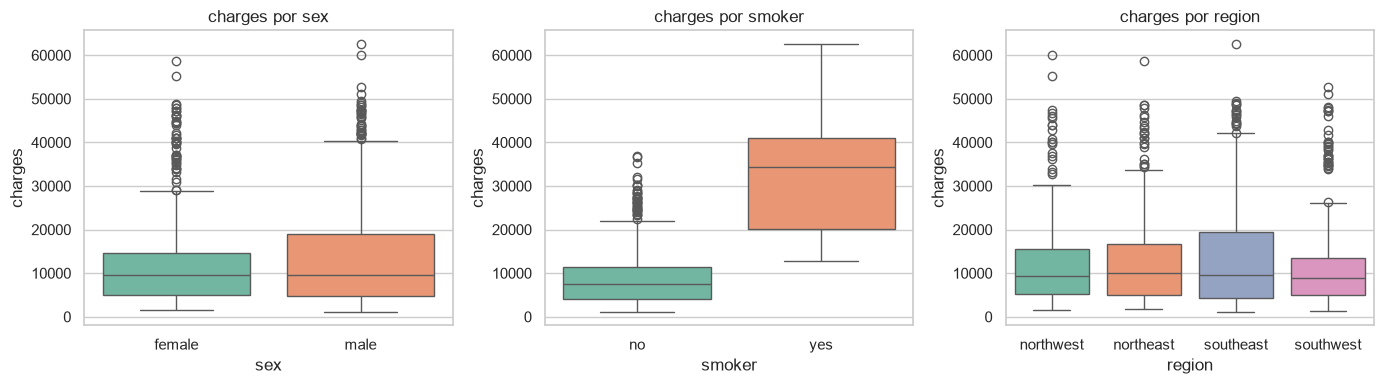

Media de charges por categoria:

-- sex --
        count     mean  median
sex                           
female    522  12647.0  9558.0
male      548  14012.0  9619.0

-- smoker --
        count     mean   median
smoker                         
no        850   8578.0   7580.0
yes       220  31767.0  34279.0

-- region --
           count     mean   median
region                            
northeast    267  13333.0  10141.0
northwest    256  12623.0   9408.0
southeast    283  14698.0   9504.0
southwest    264  12612.0   8824.0


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, CATEGORICAS):
    sns.boxplot(data=train, x=col, y=TARGET, ax=ax, palette="Set2", hue=col, legend=False)
    ax.set_title(f"charges por {col}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_charges_por_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

print("Media de charges por categoria:")
for col in CATEGORICAS:
    g = train.groupby(col)[TARGET].agg(["count", "mean", "median"]).round(0)
    print(f"\n-- {col} --")
    print(g.to_string())

**Este es el hallazgo central del EDA, y conviene leerlo con cuidado:**

| Variable | Relación con `charges` |
|---|---|
| `age` | Pearson = **0.282** (débil) |
| `bmi` | Pearson = **0.197** (débil) |
| `children` | Pearson = **0.072** (casi nula) |
| `sex` | medias \$12.647 vs \$14.012 → diferencia chica |
| `region` | medias entre \$12.612 y \$14.698 → diferencia chica |
| **`smoker`** | medias **\$8.578 vs \$31.767** → **3.7×** |

Ninguna variable numérica supera una correlación de 0.3 con el target, y sin embargo el
dataset **sí** es predecible: lo que manda es una variable **categórica**.

Esto ilustra la advertencia de la Clase 3 (slide 65): la correlación de Pearson
*"únicamente capta relaciones lineales"* y sólo aplica a variables numéricas continuas. Si
uno se guiara sólo por Pearson concluiría que este problema es casi impredecible, y estaría
equivocado.

> Por eso en la Fase 3 se agrega **información mutua** (`mutual_info_regression`, Clase 3
> slide 66), que detecta relaciones no lineales y funciona con variables de cualquier tipo.

## 2.3 Relación entre las features: ¿hay redundancia?

*"Variables con alta correlación contienen información muy similar y son probablemente
redundantes"* (Clase 3, slide 55).

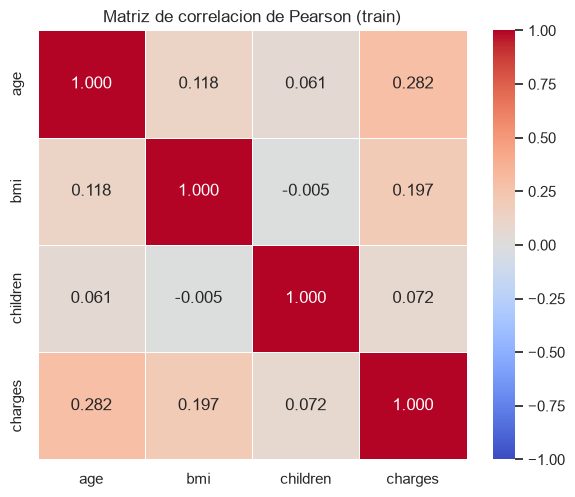

Correlacion absoluta maxima entre features: 0.118 (age - bmi)


In [15]:
corr_matrix = train[NUMERICAS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Matriz de correlacion de Pearson (train)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_matriz_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlacion maxima entre features, ignorando la diagonal (que siempre vale 1).
entre_features = corr_matrix.loc[NUMERICAS, NUMERICAS].abs()
sin_diagonal = entre_features.where(~np.eye(len(NUMERICAS), dtype=bool))
i, j = sin_diagonal.stack().idxmax()
print(f"Correlacion absoluta maxima entre features: {sin_diagonal.max().max():.3f} "
      f"({i} - {j})")

**No hay redundancia.** La correlación absoluta máxima entre features numéricas es
**0.118** (`age` con `bmi`), muy lejos de cualquier umbral que justifique descartar una
variable.

**Consecuencia para la consigna 1.4:** no hay motivo para eliminar features por
redundancia. Con 6 variables y 1070 observaciones tampoco hay problema de dimensionalidad
(la "regla del 10×" de la Clase 2 slide 91 pediría ~60 observaciones y tenemos 1070). La
decisión sobre qué features incluir se formaliza en la Fase 3.

## 2.4 El efecto conjunto: `smoker` × `bmi`

Los scatter plots son el tercer método visual de la Clase 2 (slide 40). Acá revelan algo
que ninguna correlación individual mostraba.

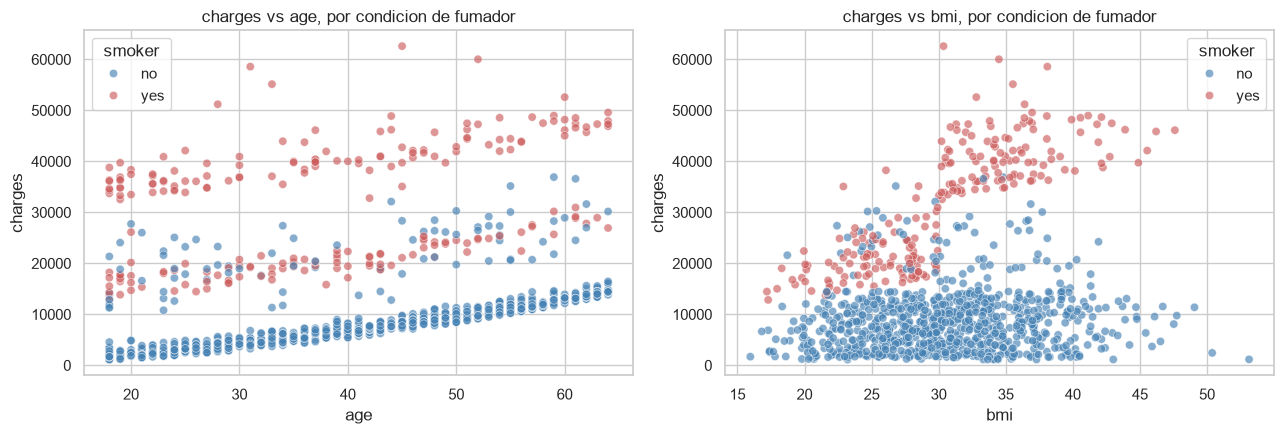

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
paleta = {"no": "steelblue", "yes": "indianred"}

for ax, col in zip(axes, ["age", "bmi"]):
    sns.scatterplot(data=train, x=col, y=TARGET, hue="smoker", palette=paleta,
                    alpha=0.65, ax=ax)
    ax.set_title(f"charges vs {col}, por condicion de fumador")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_scatter_target.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
print("Correlacion de charges con age y bmi, calculada por separado en cada grupo:")
tabla = []
for fuma in ["no", "yes"]:
    sub = train[train["smoker"] == fuma]
    tabla.append({
        "smoker": fuma,
        "n": len(sub),
        "corr_age": round(sub["age"].corr(sub[TARGET]), 3),
        "corr_bmi": round(sub["bmi"].corr(sub[TARGET]), 3),
    })
pd.DataFrame(tabla).set_index("smoker")

Correlacion de charges con age y bmi, calculada por separado en cada grupo:


,n,corr_age,corr_bmi
smoker,,,
no,850,0.619,0.090
yes,220,0.384,0.805


**Lo que muestran los scatter plots:**

- En `charges` vs `age` se ven **tres curvas paralelas** que crecen con la edad. La banda
  inferior son no fumadores; las superiores, fumadores. La relación con la edad existe,
  pero está *desplazada verticalmente* según `smoker`.
- En `charges` vs `bmi` el contraste es más fuerte: entre los **no fumadores** el costo casi
  no depende del `bmi` (nube plana), mientras que entre los **fumadores** crece de forma
  marcada. La correlación calculada por separado lo confirma.

Esto significa que **el efecto de `bmi` depende del valor de `smoker`**: es una
**interacción**. Un modelo lineal simple, que suma efectos independientes
($\beta_1 \cdot bmi + \beta_2 \cdot smoker$), no puede representarla.

> **Esta es la justificación real de la regresión polinómica de la Fase 5.** Los términos
> cruzados que genera `PolynomialFeatures` (por ejemplo $bmi \times smoker$) son
> exactamente lo que hace falta para capturar este patrón. No aplicamos la transformación
> polinómica porque el enunciado la pide: la aplicamos porque el EDA muestra que hace falta.

---

## Conclusiones de la Fase 2

### Limpieza de datos *(paso 4)*

| Problema | Hallazgo | Decisión |
|---|---|---|
| Valores faltantes | **0** en las 7 columnas | No se aplica ninguna estrategia: no hay nada que imputar ni eliminar |
| Duplicados | **0** dentro del train | Nada que eliminar (la copia gemela quedó en test, documentado en Fase 1) |
| Inconsistencias | Ninguna: todos los rangos son plausibles | No se corrige ningún registro |
| Outliers `charges` | 111 por IQR (10.4%), **97.3% fumadores** | **Se mantienen**: no son errores, son la señal principal |
| Outliers `bmi` | 6 por IQR (0.6%), obesidad severa | **Se mantienen**: plausibles y sin efecto sobre el costo medio |
| Outliers `children` | 15 por z-score: personas con 5 hijos | **Se mantienen**: valor legítimo |

### EDA *(paso 5)*

1. **`charges` es bimodal y asimétrica**, con media 39% por encima de la mediana. La
   bimodalidad se explica íntegramente por `smoker`.
2. **Ninguna variable numérica correlaciona fuerte con el target** (máximo 0.282). El
   predictor dominante es categórico: `smoker`, con una diferencia de medias de 3.7×.
3. **No hay redundancia entre features** (correlación máxima 0.118), ni problema de
   dimensionalidad.
4. **Existe una interacción `smoker` × `bmi`**: el `bmi` casi no afecta el costo de los no
   fumadores, pero sí el de los fumadores. Un modelo puramente lineal no puede capturarla.

### Qué queda planteado para las fases siguientes

- **Fase 3:** encoding de las categóricas (con `smoker` como la variable clave), escalado
  z-score, evaluación de una transformación logarítmica del target, y filtros de selección
  con información mutua.
- **Fase 5:** la regresión polinómica no es un requisito formal del enunciado sino la
  respuesta a la interacción detectada acá.

**Siguiente:** Fase 3 — Preprocesamiento y features (paso 6 del pipeline, consignas 1.1 y 1.4).